# User Engagement Dashboard Analysis

This analysis explores user behavior on the platform between 2020 and 2023.  
The goal is to understand subscription trends, class participation, user activity by country, top engaged users, and the most popular categories.

In [984]:
#Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express  as px

#import dataset
df = pd.read_csv(r'C:\Users\Usuario\Desktop\Esame_Finale_S2I\Lifestyle_data Final Project.csv')

## Data overview

Before starting the analysis, the dataset is inspected to understand its structure, data types, and possible missing values. [file:1162]

In [986]:
print("Dataset shape:", df.shape)
print("-" * 50)
display(df.head())
print("-" * 50)
print("Missing values:")
print(df.isnull().sum())


Dataset shape: (999, 12)
--------------------------------------------------


,class_date,user_uuid,category,coach_id,language,level,challenge_id,country,subscription_date,platform,class_id,stars
0,1-2-2023,2,meditation,102,it,basic,3,it,6-1-2022,tv,2157,1
1,22-5-2023,241,power yoga,111,it,basic,1,it,11-5-2022,pc,6172,3
2,6-8-2022,173,power yoga,117,it,advanced,3,it,12-12-2021,pc,6255,2
3,8-8-2023,217,hatha,100,en,intermediate,3,uk,7-2-2022,tv,3317,4
4,11-3-2022,230,power yoga,113,fr,basic,2,fr,9-1-2020,pc,6159,1


--------------------------------------------------
Missing values:
class_date           0
user_uuid            0
category             0
coach_id             0
language             0
level                0
challenge_id         0
country              0
subscription_date    0
platform             0
class_id             0
stars                0
dtype: int64


## Data cleaning and preprocessing

To make the analysis more consistent, column names are standardized and date fields are converted into datetime format.  
Additional time-based features are created to support yearly, monthly, and quarterly analysis. [file:1162]

In [987]:
df = df.rename(columns={'user_uuid':'user_id'})

df["subscription_date"] = pd.to_datetime(df["subscription_date"], dayfirst=True)
df["class_date"] = pd.to_datetime(df["class_date"], dayfirst=True)

df["year"] = df["class_date"].dt.year
df["month"] = df["class_date"].dt.to_period("M")
df["quarter"] = df["class_date"].dt.to_period("Q")

In [989]:
display(df.head())

,class_date,user_id,category,coach_id,language,level,challenge_id,country,subscription_date,platform,class_id,stars,year,month,quarter
0,2023-02-01,2,meditation,102,it,basic,3,it,2022-01-06,tv,2157,1,2023,2023-02,2023Q1
1,2023-05-22,241,power yoga,111,it,basic,1,it,2022-05-11,pc,6172,3,2023,2023-05,2023Q2
2,2022-08-06,173,power yoga,117,it,advanced,3,it,2021-12-12,pc,6255,2,2022,2022-08,2022Q3
3,2023-08-08,217,hatha,100,en,intermediate,3,uk,2022-02-07,tv,3317,4,2023,2023-08,2023Q3
4,2022-03-11,230,power yoga,113,fr,basic,2,fr,2020-01-09,pc,6159,1,2022,2022-03,2022Q1


## Coach performance analysis

Coach ratings provide an initial view of perceived class quality.  
Identifying the best and worst rated coaches can help highlight strengths and potential improvement areas in the learning experience. [file:1162]

In [1002]:
coach_ratings = df.groupby('coach_id')['stars'].mean().sort_values(ascending=False).reset_index(name='avg_stars')
Global_avg = df.stars.mean()
best_coaches = coach_ratings.head(5)
worst_coaches = coach_ratings.tail(5)

coach_summary = pd.concat([best_coaches, worst_coaches]).reset_index(drop=True)
coach_summary.index = coach_summary.index + 1

The ranking highlights the coaches with the highest and lowest average ratings.  
This comparison can support a deeper qualitative review of teaching style, content quality, or user satisfaction drivers. 

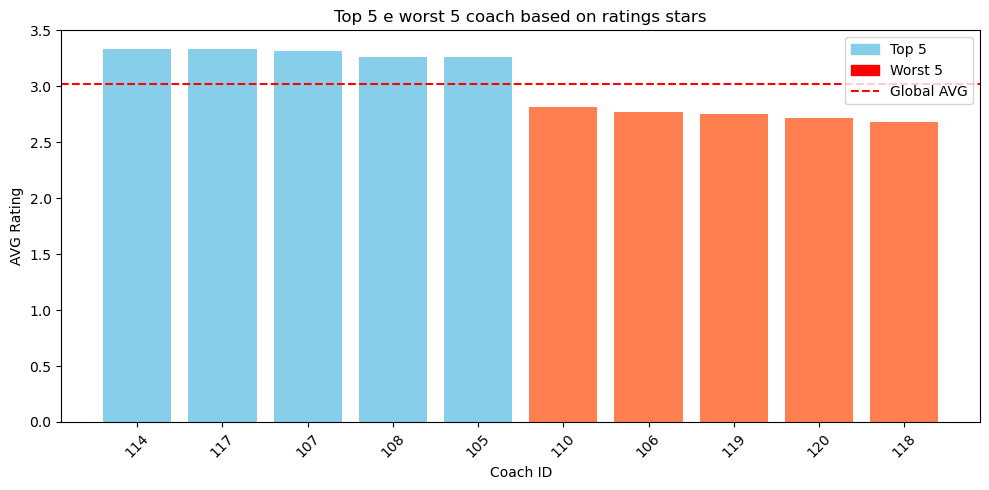

In [1005]:
fig, ax = plt.subplots(figsize=(10, 5))
colors = ['skyblue'] *5 + ['coral']*5

ax.bar(
    coach_summary.index,                
    coach_summary['avg_stars'],                 
    tick_label=coach_summary['coach_id'] ,
    color = colors
)

ax.axhline(Global_avg, color='red', linestyle='--', label='Global AVG')
ax.set_xlabel('Coach ID')
ax.set_ylabel('AVG Rating')
ax.set_title('Top 5 e worst 5 coach based on ratings stars')
ax.legend(handles=[
    plt.Rectangle((0,0), 1, 1, color='skyblue', label='Top 5'),
    plt.Rectangle((0,0), 1, 1, color='red', label='Worst 5'),
    plt.Line2D([0], [0], color='red', linestyle='--', label='Global AVG')
])
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

The statistics are significant since all of them have a number of classes considered sufficient.

In [810]:
df.groupby('coach_id')['class_id'].count().sort_values(ascending=False)

coach_id
111    55
115    53
105    53
106    52
122    52
110    49
116    49
109    49
119    49
100    44
107    44
120    42
112    42
118    41
101    40
117    39
114    39
102    37
104    37
121    36
113    34
108    34
103    29
Name: class_id, dtype: int64

## Unique users signed up (2020–2022)

This section focuses on subscription behavior over time.  
The metric is based on distinct users grouped by subscription date, which helps track platform growth and acquisition trends.

In [ ]:
signups_over_time = (
    df.groupby(df["subscription_date"].dt.to_period("Q"))["user_id"].nunique()
    )

signups_by_country = (
    df.groupby(["country", df["subscription_date"].dt.to_period("Q")])["user_id"].nunique().reset_index(name="unique_signups")
)

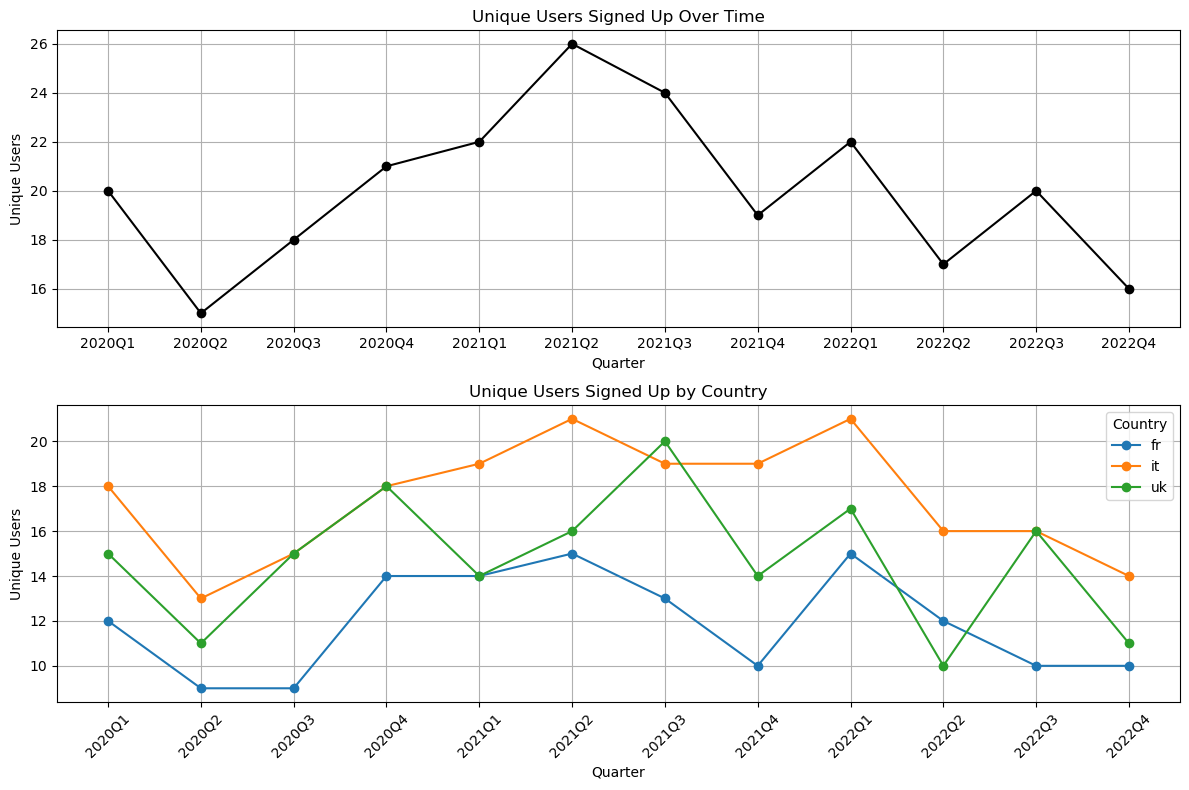

In [1007]:
fig, ax = plt.subplots(2, 1, figsize=(12, 8))

ax[0].plot(signups_over_time.index.astype(str), signups_over_time.values,
           marker="o", color="black")
ax[0].set_title("Unique Users Signed Up Over Time")
ax[0].set_xlabel("Quarter")
ax[0].set_ylabel("Unique Users")
ax[0].grid(True)

for country in signups_by_country["country"].unique():
    temp = signups_by_country[signups_by_country["country"] == country]
    ax[1].plot(temp["subscription_date"].astype(str), temp["unique_signups"],
               marker="o", label=country)

ax[1].set_title("Unique Users Signed Up by Country")
ax[1].set_xlabel("Quarter")
ax[1].set_ylabel("Unique Users")
ax[1].legend(title="Country")
ax[1].grid(True)

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

Sign-up trends are not perfectly linear, but they provide a useful view of how user acquisition evolves over time.  
Breaking the metric down by country also helps identify which markets contribute most to subscription growth.

## Active unique users by country

In addition to subscriptions, active users provide a stronger measure of engagement.  
Here, an active user is defined as a distinct user who attended at least one class in the selected year.

In [1008]:
active_users_by_country = (
    df.groupby(["year", "country"])["user_id"]
      .nunique()
      .reset_index(name="active_users")
)

active_users_by_country = active_users_by_country[
    active_users_by_country["year"].isin([2021, 2022, 2023])
]

active_users_by_country

,year,country,active_users
0,2021,fr,21
1,2021,it,28
2,2021,uk,25
3,2022,fr,52
4,2022,it,97
5,2022,uk,72
6,2023,fr,97
7,2023,it,155
8,2023,uk,121


The results show progressive growth in active users across all countries.  
For example, in 2023 the platform records 155 active users in Italy, 121 in the UK, and 97 in France, suggesting a broad increase in engagement.

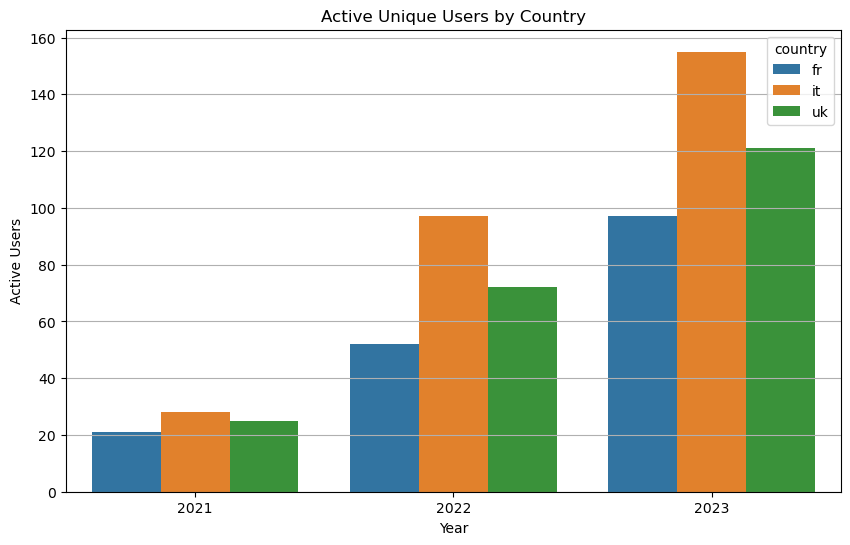

In [1009]:
plt.figure(figsize=(10, 6))
sns.barplot(data=active_users_by_country, x="year", y="active_users", hue="country")
plt.title("Active Unique Users by Country")
plt.xlabel("Year")
plt.ylabel("Active Users")
plt.grid(axis="y")
plt.show()

## Ratings over time

In addition to analyzing the growth in the number of reviews, it is also useful to examine how ratings evolved over time.  
This helps determine whether the platform improved not only in terms of user participation, but also in the perceived quality of the classes. 

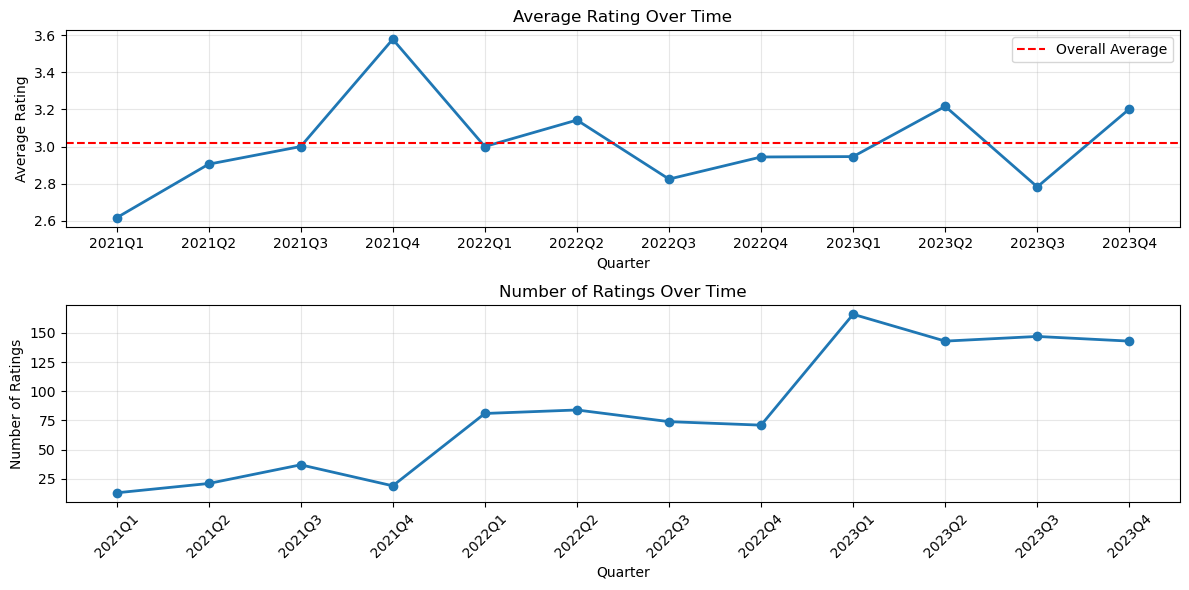

In [ ]:
stars_per_quarter = (
    df.groupby("quarter").agg(
        avg_rating=("stars", "mean"), 
        rating_count=("stars", "count")
      ).reset_index()
)

fig, axes = plt.subplots(2, 1, figsize=(12, 6))

axes[0].plot(
    stars_per_quarter["quarter"].astype(str),
    stars_per_quarter["avg_rating"],
    marker="o",
    linewidth=2
)

axes[0].set_title("Average Rating Over Time")
axes[0].axhline(Global_avg, color="red", linestyle="--", label="Overall Average")
axes[0].set_xlabel("Quarter")
axes[0].set_ylabel("Average Rating")
axes[0].legend()
axes[0].grid(alpha=0.3)

axes[1].plot(
    stars_per_quarter["quarter"].astype(str),
    stars_per_quarter["rating_count"],
    marker="o",
    linewidth=2
)

axes[1].set_title("Number of Ratings Over Time")
axes[1].set_xlabel("Quarter")
axes[1].set_ylabel("Number of Ratings")
axes[1].grid(alpha=0.3)

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

The data suggests that, while the number of ratings submitted increased gradually, the perceived quality did not show a consistent improvement over time. Ratings remained fluctuating from one period to another, indicating that the growth in participation did not translate into a linear increase in satisfaction. The causes of this variability may be multiple and should be further investigated through additional analyses, for example by considering possible changes in costs, course offerings, or lesson quality.


## YEAR 2023
A specific focus on 2023 makes it easier to compare the current distribution 

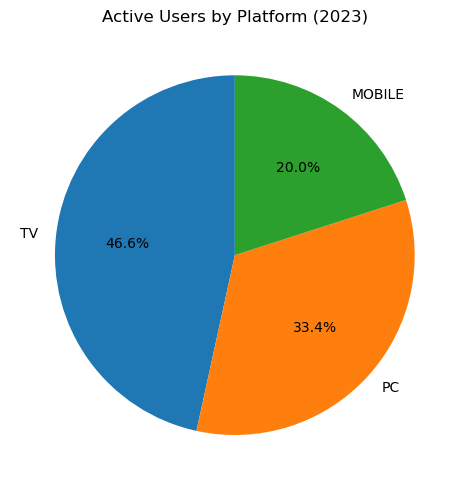

In [1014]:
active_users_2023 = df[df["year"] == 2023]

platform_distribution_2023 = (
    active_users_2023["platform"]
    .value_counts()
    .sort_values(ascending=False)
)

fig, ax = plt.subplots(figsize=(8, 5))

platform_distribution_2023.plot.pie(
    ax=ax,
    autopct="%1.1f%%",
    startangle=90,
    labels=platform_distribution_2023.index.str.upper()
)

ax.set_ylabel("")
ax.set_title("Active Users by Platform (2023)")

plt.tight_layout()
plt.show()

## Number of classes attended by users

This analysis measures how many classes each user attended.  
It helps identify whether usage is concentrated among a few highly engaged users or distributed more evenly across the user base.

In [1017]:
classes_per_user = (
    df.groupby("user_id")["class_id"]
      .count()
      .reset_index(name="total_classes")
      .sort_values("total_classes", ascending=False)
)

classes_per_user

,user_id,total_classes
96,100,12
231,237,12
186,190,10
13,15,9
89,93,9
...,...,...
147,151,1
153,157,1
187,191,1
202,208,1


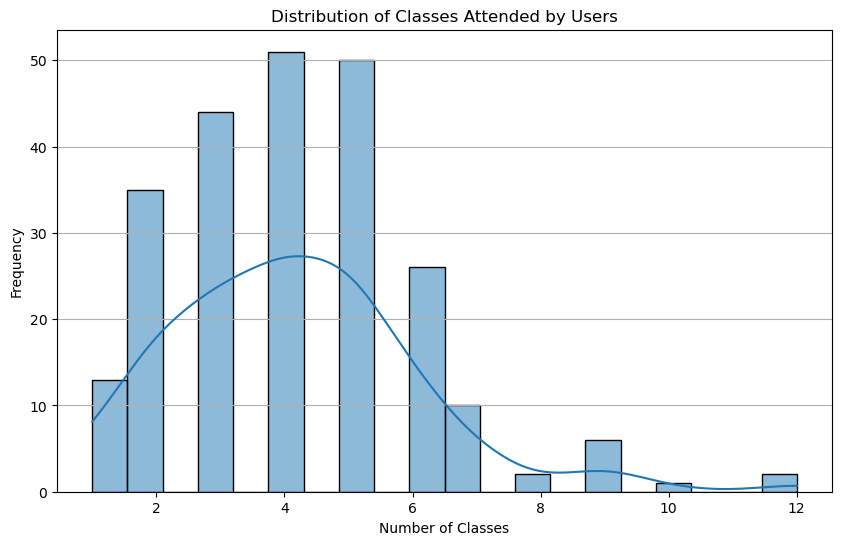

In [1016]:
plt.figure(figsize=(10, 6))
sns.histplot(classes_per_user["total_classes"], bins=20, kde=True)
plt.title("Distribution of Classes Attended by Users")
plt.xlabel("Number of Classes")
plt.ylabel("Frequency")
plt.grid(axis="y")
plt.show()

## Most active users in 2023

This ranking identifies the users with the highest number of attended classes in 2023.  
It is useful for detecting highly engaged profiles and understanding the upper end of platform usage.

In [1035]:
df_2023 = df[df["year"] == 2023]

most_active_users_2023 = (
    df_2023.groupby("user_id")["class_id"]
           .count()
           .reset_index(name="total_classes")
           .sort_values("total_classes", ascending=False)
           .head(10)
)

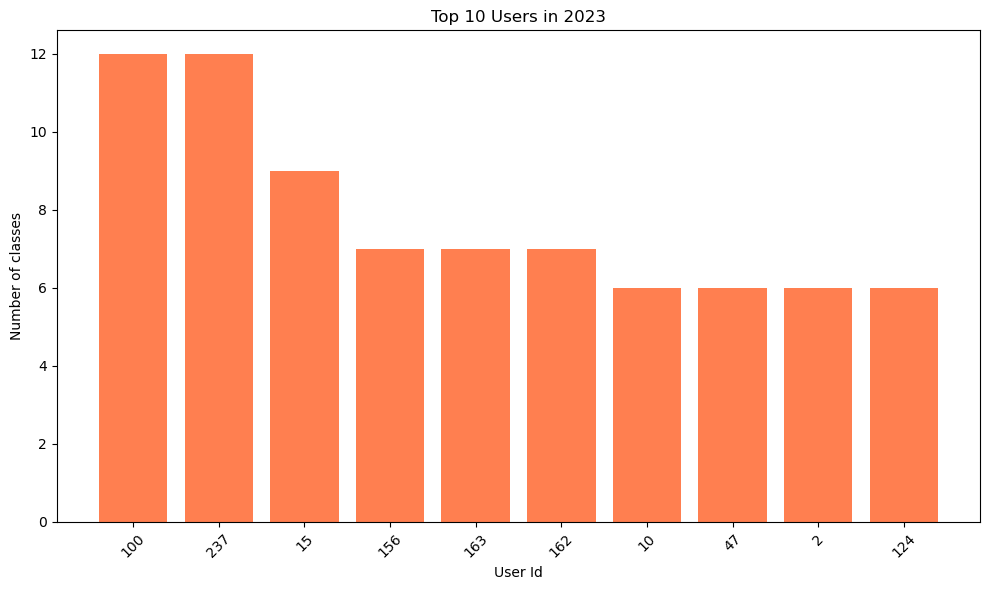

In [1037]:
top_ten_users_2023 = most_active_users_2023.head(10)

plt.figure(figsize=(10, 6))
plt.bar(most_active_users_2023['user_id'].astype(str), most_active_users_2023['total_classes'], color='coral')
plt.title('Top 10 Users in 2023')
plt.xlabel('User Id')
plt.ylabel('Number of classes')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

The top users in this ranking represent the most engaged segment of the platform in 2023.  
These users may be useful for retention analysis, loyalty initiatives, or advanced behavioral segmentation

## Most popular categories in 2023

Category popularity is measured through the number of attended classes in 2023.  
This allows us to identify which content areas attract the highest level of user interest and participation.

In [1023]:
top_categories_2023 = (
    df_2023.groupby("category")["class_id"]
           .count()
           .reset_index(name="total_classes")
           .sort_values("total_classes", ascending=False)
)

top_categories_2023

,category,total_classes
2,power yoga,245
3,vinyasa,169
0,hatha,105
1,meditation,80


C:\Users\Usuario\AppData\Local\Temp\ipykernel_6740\688851682.py:2: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.




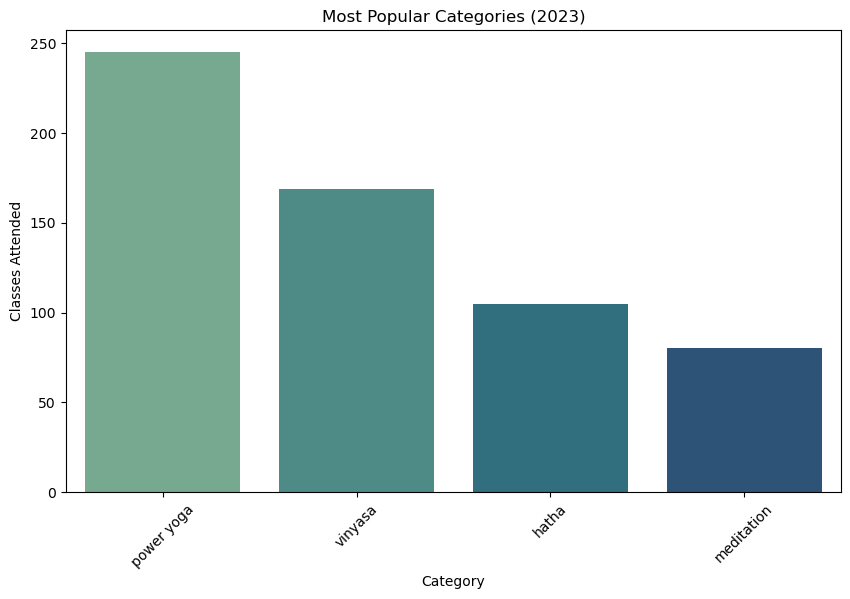

In [1027]:
plt.figure(figsize=(10, 6))
sns.barplot(data=top_categories_2023, x="category", y="total_classes", palette='crest')
plt.title("Most Popular Categories (2023)")
plt.xlabel("Category")
plt.ylabel("Classes Attended")
plt.xticks(rotation=45)
plt.show()

The most popular categories highlight the areas where user demand is strongest.  
This insight can support content planning, instructor allocation, and future course development decisions. 

## Average rating by category and level

To deepen the quality analysis, it is useful to compare average ratings across categories and difficulty levels in 2023.  
This heatmap helps identify which combinations receive higher user satisfaction and which ones may require further attention.

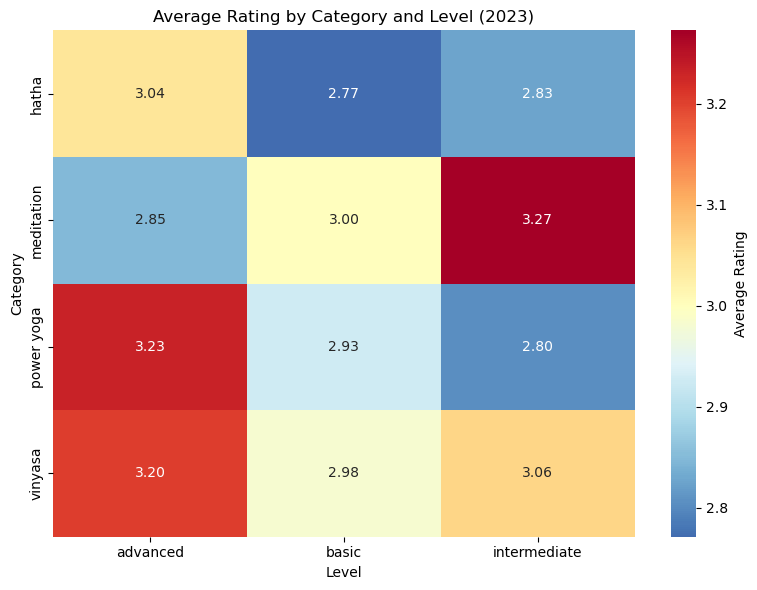

In [1038]:
avg_rating_by_category_level_2023 = df_2023.pivot_table(
    index="category",
    columns="level",
    values="stars",
    aggfunc="mean"
)

plt.figure(figsize=(8, 6))
sns.heatmap(
    avg_rating_by_category_level_2023,
    annot=True,
    fmt=".2f",
    cmap="RdYlBu_r",
    center=avg_rating_by_category_level_2023.values.mean(),
    cbar_kws={"label": "Average Rating"}
)

plt.title("Average Rating by Category and Level (2023)")
plt.xlabel("Level")
plt.ylabel("Category")
plt.tight_layout()
plt.show()

In [829]:
df.to_csv('lifestyle_data Final Project.csv',index=False)

## Final insights

The analysis shows that the platform experienced a positive evolution in user engagement over time.  
While sign-up trends fluctuate across periods, active users increased steadily, suggesting stronger recurring participation.

Italy emerges as the most active country in 2023, and category-level analysis highlights the content areas that drive the highest class attendance.  